In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import os
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from sklearn.linear_model import LinearRegression

def calculate_sensitivity(df, param_names):
    """
    与えられたデータフレームに対してパラメータ感度と寄与率を計算する

    Parameters:
    df (pandas.DataFrame): 分析対象のデータフレーム
    param_names (list): 感度分析を行うパラメータ名のリスト

    Returns:
    dict: 各パラメータの感度と寄与率を含む辞書
    """
    # 入力と出力を準備
    X = df[param_names].copy()
    y = df['target_metric'].copy()
    
    # データを標準化
    X_mean = X.mean()
    X_std = X.std()
    y_mean = y.mean()
    y_std = y.std()
    
    # 標準偏差が0の場合は正規化を回避
    X_std = X_std.replace(0, 1)
    if y_std == 0:
        y_std = 1
    
    X_norm = (X - X_mean) / X_std
    y_norm = (y - y_mean) / y_std
    
    # 線形回帰で感度を計算
    model = LinearRegression()
    model.fit(X_norm, y_norm)
    
    # 標準化された回帰係数（感度）
    coefficients = model.coef_
    
    # 寄与率計算
    abs_coefficients = np.abs(coefficients)
    total_effect = np.sum(abs_coefficients)
    
    if total_effect == 0:
        # 全係数が0の場合、均等に寄与
        contributions = np.ones_like(coefficients) / len(coefficients)
    else:
        contributions = abs_coefficients / total_effect
    
    # 結果を辞書として返す
    result = {}
    for i, param in enumerate(param_names):
        result[f'{param}_sensitivity'] = abs_coefficients[i]
        result[f'{param}_contribution'] = contributions[i]
    
    return result


def analyze_simulation_results_3d_segments(results_csv_path, output_dir, param_names=None, 
                                          target_column='total_time', num_segments=3, 
                                          segment_method='quantile', min_samples=4):
    """
    データの分布に基づいて自動的にパラメータ範囲を分割し、3次元セグメントごとに感度分析を行う関数
    
    Parameters:
    results_csv_path (str): シミュレーション結果を含むCSVファイルのパス
    output_dir (str): 出力ファイルを保存するディレクトリ
    param_names (list): 分析対象のパラメータ名リスト
    target_column (str): 目標メトリック列の名前
    num_segments (int): 各パラメータを分割するセグメント数（デフォルト: 3）
    segment_method (str): 分割方法 ('quantile'=分位数, 'log'=対数間隔, 'linear'=線形間隔)
    min_samples (int): セグメントの最小サンプル数（これより少ないセグメントは分析から除外）
    
    Returns:
    dict: 各パラメータセグメントの感度分析結果を含む辞書
    """
    # 出力ディレクトリを作成
    os.makedirs(output_dir, exist_ok=True)
    
    # シミュレーション結果の読み込み
    results_df = pd.read_csv(results_csv_path)
    print(f"CSVから{len(results_df)}件のシミュレーション結果を読み込みました: {results_csv_path}")
    
    # パラメータ名の設定
    if param_names is None:
        # CSV列名からパラメータ名を推測
        if 'coherence_time' in results_df.columns and 'entanglement_fidelity' in results_df.columns and 'noise_rate' in results_df.columns:
            param_names = ['coherence_time', 'entanglement_fidelity', 'noise_rate']
            # ターゲット列が指定されていない場合、デフォルトの'target_metric'を使用
            if target_column == 'total_time' and 'target_metric' in results_df.columns:
                target_column = 'target_metric'
        elif 'distance' in results_df.columns and 'entanglement_speed_factor' in results_df.columns and 'gate_speed_factor' in results_df.columns:
            param_names = ['distance', 'entanglement_speed_factor', 'gate_speed_factor']
            # ターゲット列が指定されていない場合、デフォルトの'total_time'を使用
            if target_column != 'total_time' and 'total_time' in results_df.columns:
                target_column = 'total_time'
        else:
            raise ValueError("パラメータ名を自動検出できませんでした。param_namesを明示的に指定してください。")
    
    # ターゲット列名が存在するかチェック
    if target_column not in results_df.columns:
        raise ValueError(f"指定されたターゲット列 '{target_column}' がCSVに存在しません。")
    
    # ターゲット列名を統一
    if target_column != 'target_metric':
        results_df['target_metric'] = results_df[target_column]
    
    # パラメータの対数変換（ビジュアライゼーション用）
    for param in param_names:
        if (results_df[param] <= 0).any():
            min_positive = results_df[param][results_df[param] > 0].min()
            results_df[f'log_{param}'] = np.log10(results_df[param] + min_positive * 0.1)
        else:
            results_df[f'log_{param}'] = np.log10(results_df[param])
    
    # 分割方法に基づいてセグメント境界を計算
    segment_boundaries = {}
    
    for param in param_names:
        values = results_df[param].values
        
        if segment_method == 'quantile':
            # 分位数に基づく分割（データ数が均等になる）
            quantiles = np.linspace(0, 1, num_segments + 1)
            boundaries = np.quantile(values, quantiles)
            
        elif segment_method == 'log' and np.min(values) > 0:
            # 対数スケールでの均等分割
            log_min = np.log10(np.min(values))
            log_max = np.log10(np.max(values))
            log_boundaries = np.linspace(log_min, log_max, num_segments + 1)
            boundaries = 10 ** log_boundaries
            
        else:
            # 線形スケールでの均等分割
            boundaries = np.linspace(np.min(values), np.max(values), num_segments + 1)
        
        # 境界値を一意にする（重複を排除）
        boundaries = np.unique(boundaries)
        
        # 分割数が少なくなった場合の処理
        if len(boundaries) < 3:
            print(f"警告: {param}のユニークな境界値が少なすぎます。線形分割を使用します。")
            boundaries = np.linspace(np.min(values), np.max(values), num_segments + 1)
        
        segment_boundaries[param] = boundaries
        
        print(f"\n{param}の分割境界（{segment_method}方式）:")
        for i, bound in enumerate(boundaries):
            print(f"  境界{i}: {bound:.4f}")
    
    # 結果を格納するデータフレームを初期化
    all_results = []
    # シンプル形式の結果を格納するリスト
    simple_results = []
    
    # 3パラメータの組み合わせによる3次元セグメント分割（n×n×n分割）
    print("\n3パラメータの組み合わせセグメント分析:")
    
    # 全てのパラメータの境界を取得
    boundaries_list = [segment_boundaries[param] for param in param_names]
    
    # 3次元セグメントの全ての組み合わせでループ
    segments_total = (len(boundaries_list[0])-1) * (len(boundaries_list[1])-1) * (len(boundaries_list[2])-1)
    segments_analyzed = 0
    segments_skipped = 0
    
    for i in range(len(boundaries_list[0]) - 1):
        lower1 = boundaries_list[0][i]
        upper1 = boundaries_list[0][i + 1]
        
        for j in range(len(boundaries_list[1]) - 1):
            lower2 = boundaries_list[1][j]
            upper2 = boundaries_list[1][j + 1]
            
            for k in range(len(boundaries_list[2]) - 1):
                lower3 = boundaries_list[2][k]
                upper3 = boundaries_list[2][k + 1]
                
                segment_name = f"{param_names[0]}_{i+1}_{param_names[1]}_{j+1}_{param_names[2]}_{k+1}"
                
                # セグメントに該当するデータをフィルタリング
                segment_df = results_df[
                    (results_df[param_names[0]] >= lower1) & (results_df[param_names[0]] <= upper1) &
                    (results_df[param_names[1]] >= lower2) & (results_df[param_names[1]] <= upper2) &
                    (results_df[param_names[2]] >= lower3) & (results_df[param_names[2]] <= upper3)
                ]
                
                # サンプル数が十分かチェック
                if len(segment_df) < min_samples:
                    print(f"  警告: {segment_name}のサンプル数が不足しています: {len(segment_df)}")
                    segments_skipped += 1
                    continue
                
                print(f"  {segment_name}: サンプル数 = {len(segment_df)}")
                segments_analyzed += 1
                
                # 感度分析実行
                sensitivity_result = calculate_sensitivity(segment_df, param_names)
                
                # 結果に追加情報を付加
                result = {
                    'segment_type': '3d',
                    'segment_id': f"{i+1}_{j+1}_{k+1}",
                    'segment_name': segment_name,
                    f'{param_names[0]}_lower': lower1,
                    f'{param_names[0]}_upper': upper1,
                    f'{param_names[1]}_lower': lower2,
                    f'{param_names[1]}_upper': upper2,
                    f'{param_names[2]}_lower': lower3,
                    f'{param_names[2]}_upper': upper3,
                    'sample_size': len(segment_df)
                }
                
                # 感度分析結果を追加
                result.update(sensitivity_result)
                
                # シンプル形式用に中央値を計算
                param1_mid = (lower1 + upper1) / 2
                param2_mid = (lower2 + upper2) / 2
                param3_mid = (lower3 + upper3) / 2
                
                # セグメント内のターゲットメトリックの平均値を取得
                avg_target_metric = segment_df['target_metric'].mean()
                
                # シンプル形式の結果を追加
                simple_result = {
                    'segment_id': f"{i+1}_{j+1}_{k+1}",
                    param_names[0]: param1_mid,
                    param_names[1]: param2_mid,
                    param_names[2]: param3_mid,
                    'target_metric': avg_target_metric,
                    f'{param_names[0]}_contribution': sensitivity_result[f'{param_names[0]}_contribution'],
                    f'{param_names[1]}_contribution': sensitivity_result[f'{param_names[1]}_contribution'],
                    f'{param_names[2]}_contribution': sensitivity_result[f'{param_names[2]}_contribution']
                }
                simple_results.append(simple_result)
                
                all_results.append(result)
    
    print(f"\n3次元セグメント分析完了: 合計{segments_total}セグメント中、{segments_analyzed}セグメントを分析、{segments_skipped}セグメントをスキップ")
    
    # 結果をデータフレームに変換
    results_df = pd.DataFrame(all_results)
    simple_results_df = pd.DataFrame(simple_results)
    
    # 結果の出力
    print("\n感度分析の結果:")
    print(results_df[['segment_name', 'sample_size'] + 
                     [f'{param}_sensitivity' for param in param_names] + 
                     [f'{param}_contribution' for param in param_names]])
    
    # 結果をCSVとして保存
    output_path = os.path.join(output_dir, "3d_sensitivity_analysis_results.csv")
    results_df.to_csv(output_path, index=False)
    print(f"\n結果を保存しました: {output_path}")
    
    # シンプル形式の結果をCSVとして保存
    simple_output_path = os.path.join(output_dir, "simple_segment_results.csv")
    simple_results_df.to_csv(simple_output_path, index=False)
    print(f"シンプル形式の結果を保存しました: {simple_output_path}")
    
    return {
        'results_df': results_df,
        'segment_boundaries': segment_boundaries,
        'simple_results_df': simple_results_df
    }


def visualize_3d_results(csv_path, title=None):
    """
    3Dセグメント分析結果を視覚化する関数
    
    Parameters:
    csv_path (str): シンプル形式の結果CSVファイルのパス
    title (str): グラフのタイトル（デフォルト: None）
    """
    # CSVデータを読み込む
    data = pd.read_csv(csv_path)
    
    # パラメータ名を自動検出
    if 'coherence_time' in data.columns and 'entanglement_fidelity' in data.columns and 'noise_rate' in data.columns:
        param_names = ['coherence_time', 'entanglement_fidelity', 'noise_rate']
        target_column = 'target_metric' if 'target_metric' in data.columns else 'total_time'
    elif 'distance' in data.columns and 'entanglement_speed_factor' in data.columns and 'gate_speed_factor' in data.columns:
        param_names = ['distance', 'entanglement_speed_factor', 'gate_speed_factor']
        target_column = 'total_time' if 'total_time' in data.columns else 'target_metric'
    else:
        raise ValueError("パラメータ名を自動検出できませんでした。")
    
    # ターゲット列名の確認
    if target_column not in data.columns:
        target_column = data.columns[-4]  # 最後から4番目の列を想定
        print(f"警告: ターゲット列が見つかりませんでした。{target_column}を使用します。")
    
    # データの対数変換を行う
    for param in param_names:
        if (data[param] <= 0).any():
            min_positive = data[param][data[param] > 0].min()
            data[f'log_{param}'] = np.log10(data[param] + min_positive * 0.1)
        else:
            data[f'log_{param}'] = np.log10(data[param])
    
    # 図を作成
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # 各軸の一意の値を取得（対数変換後の値）
    log_param1 = sorted(data[f'log_{param_names[0]}'].unique())
    log_param2 = sorted(data[f'log_{param_names[1]}'].unique())
    log_param3 = sorted(data[f'log_{param_names[2]}'].unique())
    
    # 各要因がターゲットメトリックに与える影響を計算
    def calculate_impact(data, factor):
        means = data.groupby(factor)[target_column].mean()
        return means.max() - means.min()
    
    param1_impact = calculate_impact(data, param_names[0])
    param2_impact = calculate_impact(data, param_names[1])
    param3_impact = calculate_impact(data, param_names[2])
    
    # 点のサイズ設定のためのターゲットメトリックの正規化
    min_metric = data[target_column].min()
    max_metric = data[target_column].max()
    normalized_sizes = 100 + (data[target_column] - min_metric) / (max_metric - min_metric) * 900
    
    # 各データポイントに対して最も影響力のあるパラメータを決定
    # 寄与値に基づく
    data['highest_contribution'] = data[[f'{param}_contribution' for param in param_names]].idxmax(axis=1)
    
    # 寄与カラム名をよりシンプルな要因名にマッピング
    contribution_to_factor = {
        f'{param_names[0]}_contribution': param_names[0].split('_')[0],
        f'{param_names[1]}_contribution': param_names[1].split('_')[0],
        f'{param_names[2]}_contribution': param_names[2].split('_')[0]
    }
    
    # カラム名を要因名に変換
    data['dominant_factor'] = data['highest_contribution'].map(contribution_to_factor)
    
    # 3つの要因のカラーマッピングを作成
    colors = {
        param_names[0].split('_')[0]: '#CC3366',
        param_names[1].split('_')[0]: '#FFCC00',
        param_names[2].split('_')[0]: '#3366CC'
    }
    
    # 凡例ラベルを作成
    factor_labels = {
        param_names[0].split('_')[0]: f'{param_names[0]} Dominant',
        param_names[1].split('_')[0]: f'{param_names[1]} Dominant',
        param_names[2].split('_')[0]: f'{param_names[2]} Dominant'
    }
    
    # より効率的なプロット作成のため、支配的要因ごとにポイントをグループ化
    grouped_data = {}
    for factor in colors.keys():
        mask = data['dominant_factor'] == factor
        if mask.any():  # このファクターを持つポイントがある場合のみグループを作成
            grouped_data[factor] = {
                'x': data.loc[mask, f'log_{param_names[0]}'].values,
                'y': data.loc[mask, f'log_{param_names[1]}'].values,
                'z': data.loc[mask, f'log_{param_names[2]}'].values,
                'sizes': normalized_sizes[mask].values,
                'color': colors[factor],
                'label': factor_labels[factor]
            }
    
    # 支配的要因グループごとに散布図を作成
    for factor, group in grouped_data.items():
        ax.scatter(
            group['x'],
            group['y'],
            group['z'],
            s=group['sizes'],
            c=group['color'],
            alpha=0.7,
            edgecolors='black',
            label=group['label']
        )
    
    # 凡例用のカスタムハンドルを作成（サイズを統一）
    legend_handles = []
    for factor, color in colors.items():
        if factor in grouped_data:  # このファクターがデータに存在する場合のみ
            # 統一されたサイズで凡例ハンドルを作成
            legend_handles.append(
                plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                          markeredgecolor='black', markersize=15, alpha=0.7)
            )
    
    # 存在するファクターのラベルだけを取得
    legend_labels = [factor_labels[factor] for factor in colors.keys() if factor in grouped_data]
    
    # 支配的要因カテゴリの最初の凡例を追加（統一されたサイズで）
    first_legend = ax.legend(legend_handles, legend_labels, 
                            title="Dominant Factor (by contribution)", 
                            loc="upper right", 
                            bbox_to_anchor=(1.25, 0.9),
                            frameon=True,
                            fontsize=10)
    
    # 軸ラベルを設定
    ax.set_xlabel(f'{param_names[0]}', fontsize=12)
    ax.set_ylabel(f'{param_names[1]}', fontsize=12)
    ax.set_zlabel(f'{param_names[2]}', fontsize=12)
    
    # 各軸の目盛りを設定 - 科学表記法を使用し、桁数を統一
    def get_tick_positions_and_labels(log_values, num_ticks=4):
        """対数値の適切な目盛り位置と、対応する元の値のラベルを生成"""
        # 目盛りの数を減らす（より少ない数のティックを使用）
        positions = np.linspace(min(log_values), max(log_values), num_ticks)
        
        # 元の値に戻す
        original_values = 10 ** positions
        
        # 全ての軸で統一した科学表記法を使用
        labels = [f"{v:.2e}" for v in original_values]
        
        return positions, labels
    
    # 各軸の目盛り位置とラベルを取得 - より少ない数のティックを指定
    x_ticks, x_labels = get_tick_positions_and_labels(log_param1, num_ticks=4)
    y_ticks, y_labels = get_tick_positions_and_labels(log_param2, num_ticks=4)
    z_ticks, z_labels = get_tick_positions_and_labels(log_param3, num_ticks=4)
    
    # 目盛りを設定
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)
    ax.set_zticks(z_ticks)
    ax.set_zticklabels(z_labels)
    
    # タイトルを追加
    if title is None:
        title = '3D Visualization of Quantum Segment Results'
    plt.title(f'{title}\nColor: Dominant Factor by Contribution | Size: {target_column}', 
              fontsize=14)
    
    # グリッド線を追加
    ax.grid(True)
    
    # ビュー角度を調整
    ax.view_init(elev=30, azim=50)
    
    plt.tight_layout()
    return fig


if __name__ == "__main__":
    # CSVファイルのパス
    input_file = "energy_future2_1000/sobol_simulation_results.csv"  # 入力CSVファイル
    output_dir = "analysis_results"  # 出力ディレクトリ
    
    # 分析パラメータ
    num_segments = 3  # 各パラメータの分割数
    segment_method = 'quantile'  # 分割方法 ('quantile', 'log', 'linear')
    min_samples = 4  # セグメントの最小サンプル数
    
    # CSVファイルを自動検出してパラメータを判断
    print("CSVファイルを読み込んで分析します...")
    
    # 分析実行
    results = analyze_simulation_results_3d_segments(
        input_file, 
        output_dir=output_dir,
        num_segments=num_segments,
        segment_method=segment_method,
        min_samples=min_samples
    )
    
    # 結果の視覚化
    simple_results_path = os.path.join(output_dir, "simple_segment_results.csv")
    fig = visualize_3d_results(simple_results_path)
    
    # 図の保存
    plt.savefig(os.path.join(output_dir, "3d_visualization.png"), dpi=300, bbox_inches='tight')
    plt.show()

CSVファイルを読み込んで分析します...


FileNotFoundError: [Errno 2] No such file or directory: 'energy_future2_1000/sobol_simulation_results.csv'

In [ ]:
input_file = "energy_future2_1000/sobol_simulation_results.csv"  # 入力CSVファイル

In [13]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from sklearn.linear_model import LinearRegression

def analyze_simulation_results_3d_segments(results_csv_path, output_dir, param_names, 
                                          target_metric_name='target_metric',
                                          target_metric_formula=None,
                                          num_segments=3, segment_method='quantile', 
                                          min_samples=4):
    """
    データの分布に基づいて自動的にパラメータ範囲を分割し、3次元セグメントごとに感度分析を行う関数
    
    Parameters:
    results_csv_path (str): シミュレーション結果を含むCSVファイルのパス
    output_dir (str): 出力ファイルを保存するディレクトリ
    param_names (list): 分析する3つのパラメータ名のリスト
    target_metric_name (str): 目標指標の名前（CSVに既にある場合はその列名、ない場合は新しく作成する列名）
    target_metric_formula (callable): 目標指標を計算する関数、Noneの場合はCSVから直接読み込み
    num_segments (int): 各パラメータを分割するセグメント数（デフォルト: 3）
    segment_method (str): 分割方法 ('quantile'=分位数, 'log'=対数間隔, 'linear'=線形間隔)
    min_samples (int): セグメントの最小サンプル数（これより少ないセグメントは分析から除外）
    
    Returns:
    dict: 各パラメータセグメントの感度分析結果を含む辞書
    """
    # 出力ディレクトリを作成
    os.makedirs(output_dir, exist_ok=True)
    
    # シミュレーション結果の読み込み
    results_df = pd.read_csv(results_csv_path)
    print(f"CSVから{len(results_df)}件のシミュレーション結果を読み込みました: {results_csv_path}")
    
    # 目標指標の設定
    if target_metric_formula is not None:
        # 指定された関数で目標指標を計算
        results_df[target_metric_name] = target_metric_formula(results_df)
        print(f"目標指標 '{target_metric_name}' を計算しました")
    elif target_metric_name not in results_df.columns:
        # デフォルトではCSVの'total_time'列を使用
        if 'total_time' in results_df.columns:
            results_df[target_metric_name] = results_df['total_time']
            print(f"目標指標として 'total_time' を使用します")
        elif 'final_energy' in results_df.columns:
            # もしくは'final_energy'が存在する場合、エネルギー誤差を計算
            results_df[target_metric_name] = abs(results_df['final_energy'] - (-1.1516))
            print(f"目標指標を計算しました: |final_energy - (-1.1516)|")
        else:
            raise ValueError(f"目標指標 '{target_metric_name}' がCSVに見つからず、計算方法も指定されていません")
    
    # 分割方法に基づいてセグメント境界を計算
    segment_boundaries = {}
    
    for param in param_names:
        values = results_df[param].values
        
        if segment_method == 'quantile':
            # 分位数に基づく分割（データ数が均等になる）
            quantiles = np.linspace(0, 1, num_segments + 1)
            boundaries = np.quantile(values, quantiles)
            
        elif segment_method == 'log' and np.min(values) > 0:
            # 対数スケールでの均等分割
            log_min = np.log10(np.min(values))
            log_max = np.log10(np.max(values))
            log_boundaries = np.linspace(log_min, log_max, num_segments + 1)
            boundaries = 10 ** log_boundaries
            
        else:
            # 線形スケールでの均等分割
            boundaries = np.linspace(np.min(values), np.max(values), num_segments + 1)
        
        # 境界値を一意にする（重複を排除）
        boundaries = np.unique(boundaries)
        
        # 分割数が少なくなった場合の処理
        if len(boundaries) < 3:
            print(f"警告: {param}のユニークな境界値が少なすぎます。線形分割を使用します。")
            boundaries = np.linspace(np.min(values), np.max(values), num_segments + 1)
        
        segment_boundaries[param] = boundaries
        
        print(f"\n{param}の分割境界（{segment_method}方式）:")
        for i, bound in enumerate(boundaries):
            # 非常に小さい値のための特別な表示形式
            if abs(bound) < 0.001:
                print(f"  境界{i}: {bound:.8e}")
            else:
                print(f"  境界{i}: {bound:.4f}")
    
    # 結果を格納するデータフレームを初期化
    all_results = []
    # シンプル形式の結果を格納するリスト
    simple_results = []
    
    # 3パラメータの組み合わせによる3次元セグメント分割（n×n×n分割）
    print("\n3パラメータの組み合わせセグメント分析:")
    
    # 全てのパラメータの境界を取得
    boundaries_list = [segment_boundaries[param] for param in param_names]
    
    # 3次元セグメントの全ての組み合わせでループ
    segments_total = (len(boundaries_list[0])-1) * (len(boundaries_list[1])-1) * (len(boundaries_list[2])-1)
    segments_analyzed = 0
    segments_skipped = 0
    
    for i in range(len(boundaries_list[0]) - 1):
        lower1 = boundaries_list[0][i]
        upper1 = boundaries_list[0][i + 1]
        
        for j in range(len(boundaries_list[1]) - 1):
            lower2 = boundaries_list[1][j]
            upper2 = boundaries_list[1][j + 1]
            
            for k in range(len(boundaries_list[2]) - 1):
                lower3 = boundaries_list[2][k]
                upper3 = boundaries_list[2][k + 1]
                
                segment_name = f"{param_names[0]}_{i+1}_{param_names[1]}_{j+1}_{param_names[2]}_{k+1}"
                
                # セグメントに該当するデータをフィルタリング
                segment_df = results_df[
                    (results_df[param_names[0]] >= lower1) & (results_df[param_names[0]] <= upper1) &
                    (results_df[param_names[1]] >= lower2) & (results_df[param_names[1]] <= upper2) &
                    (results_df[param_names[2]] >= lower3) & (results_df[param_names[2]] <= upper3)
                ]
                
                # サンプル数が十分かチェック
                if len(segment_df) < min_samples:
                    print(f"  警告: {segment_name}のサンプル数が不足しています: {len(segment_df)}")
                    segments_skipped += 1
                    continue
                
                print(f"  {segment_name}: サンプル数 = {len(segment_df)}")
                segments_analyzed += 1
                
                # 感度分析実行
                sensitivity_result = calculate_sensitivity(segment_df, param_names, target_metric_name)
                
                # 結果に追加情報を付加
                result = {
                    'segment_type': '3d',
                    'segment_id': f"{i+1}_{j+1}_{k+1}",
                    'segment_name': segment_name,
                    f'{param_names[0]}_lower': lower1,
                    f'{param_names[0]}_upper': upper1,
                    f'{param_names[1]}_lower': lower2,
                    f'{param_names[1]}_upper': upper2,
                    f'{param_names[2]}_lower': lower3,
                    f'{param_names[2]}_upper': upper3,
                    'sample_size': len(segment_df)
                }
                
                # 感度分析結果を追加
                result.update(sensitivity_result)
                
                # シンプル形式用に中点を対数軸で計算（対数値の平均を取り、その後に10の累乗を適用）
                if segment_method == 'log' and min(lower1, lower2, lower3) > 0:
                    param1_mid = 10 ** ((np.log10(lower1) + np.log10(upper1)) / 2)
                    param2_mid = 10 ** ((np.log10(lower2) + np.log10(upper2)) / 2)
                    param3_mid = 10 ** ((np.log10(lower3) + np.log10(upper3)) / 2)
                else:
                    # 線形中点計算
                    param1_mid = (lower1 + upper1) / 2
                    param2_mid = (lower2 + upper2) / 2
                    param3_mid = (lower3 + upper3) / 2
                
                # セグメント内の目標指標の平均値を取得
                avg_target_metric = segment_df[target_metric_name].mean()
                
                # シンプル形式の結果を追加
                simple_result = {
                    'segment_id': f"{i+1}_{j+1}_{k+1}",
                    param_names[0]: param1_mid,
                    param_names[1]: param2_mid,
                    param_names[2]: param3_mid,
                    target_metric_name: avg_target_metric
                }
                
                # 感度寄与率を追加
                for param in param_names:
                    simple_result[f'{param}_contribution'] = sensitivity_result[f'{param}_contribution']
                
                simple_results.append(simple_result)
                all_results.append(result)
    
    print(f"\n3次元セグメント分析完了: 合計{segments_total}セグメント中、{segments_analyzed}セグメントを分析、{segments_skipped}セグメントをスキップ")
    
    # 結果をデータフレームに変換
    results_df = pd.DataFrame(all_results)
    simple_results_df = pd.DataFrame(simple_results)
    
    # 結果の出力
    print("\n感度分析の結果:")
    print(results_df[['segment_name', 'sample_size'] + 
                     [f'{param}_sensitivity' for param in param_names] + 
                     [f'{param}_contribution' for param in param_names]])
    
    # 結果をCSVとして保存
    output_path = os.path.join(output_dir, "3d_sensitivity_analysis_results.csv")
    results_df.to_csv(output_path, index=False)
    print(f"\n結果を保存しました: {output_path}")
    
    # シンプル形式の結果をCSVとして保存
    simple_output_path = os.path.join(output_dir, "simple_segment_results.csv")
    simple_results_df.to_csv(simple_output_path, index=False)
    print(f"シンプル形式の結果を保存しました: {simple_output_path}")
    
    return {
        'results_df': results_df,
        'segment_boundaries': segment_boundaries,
        'simple_results_df': simple_results_df
    }


def calculate_sensitivity(df, param_names, target_metric_name):
    """
    与えられたデータフレームに対してパラメータ感度と寄与率を計算する

    Parameters:
    df (pandas.DataFrame): 分析対象のデータフレーム
    param_names (list): 感度分析を行うパラメータ名のリスト
    target_metric_name (str): 目標指標の列名

    Returns:
    dict: 各パラメータの感度と寄与率を含む辞書
    """
    # 入力と出力を準備
    X = df[param_names].copy()
    y = df[target_metric_name].copy()
    
    # データを標準化
    X_mean = X.mean()
    X_std = X.std()
    y_mean = y.mean()
    y_std = y.std()
    
    # 標準偏差が0の場合は正規化を回避
    X_std = X_std.replace(0, 1)
    if y_std == 0:
        y_std = 1
    
    X_norm = (X - X_mean) / X_std
    y_norm = (y - y_mean) / y_std
    
    # 線形回帰で感度を計算
    model = LinearRegression()
    model.fit(X_norm, y_norm)
    
    # 標準化された回帰係数（感度）
    coefficients = model.coef_
    
    # 寄与率計算
    abs_coefficients = np.abs(coefficients)
    total_effect = np.sum(abs_coefficients)
    
    if total_effect == 0:
        # 全係数が0の場合、均等に寄与
        contributions = np.ones_like(coefficients) / len(coefficients)
    else:
        contributions = abs_coefficients / total_effect
    
    # 結果を辞書として返す
    result = {}
    for i, param in enumerate(param_names):
        result[f'{param}_sensitivity'] = abs_coefficients[i]
        result[f'{param}_contribution'] = contributions[i]
    
    return result


def visualize_3d_segments(csv_path, param_names=None, target_metric_name=None, output_file=None, invert_x_axis=False):
    """
    3Dセグメント結果を可視化する関数
    
    Parameters:
    csv_path (str): 分析結果のCSVファイルパス
    param_names (list): 3つのパラメータ名のリスト、Noneの場合CSVから自動検出
    target_metric_name (str): 目標指標の名前、Noneの場合CSVから自動検出
    output_file (str): 出力ファイルパス、Noneの場合は画面に表示
    invert_x_axis (bool): X軸の向きを反転するかどうか
    """
    # CSVデータを読み込む
    data = pd.read_csv(csv_path)
    
    # パラメータ名を自動検出（_contributionの接尾辞を持つ列から）
    if param_names is None:
        contribution_columns = [col for col in data.columns if col.endswith('_contribution')]
        param_names = [col.replace('_contribution', '') for col in contribution_columns]
        if len(param_names) != 3:
            print(f"警告: パラメータ名の自動検出に失敗しました。3つではなく{len(param_names)}個検出されました。")
            if len(param_names) > 3:
                param_names = param_names[:3]
            elif len(param_names) < 3:
                raise ValueError("パラメータ名を手動で指定してください。")
    
    # 目標指標を自動検出
    if target_metric_name is None:
        possible_metrics = ['target_metric', 'total_time']
        for metric in possible_metrics:
            if metric in data.columns:
                target_metric_name = metric
                break
        if target_metric_name is None:
            # 最後の非パラメータ、非寄与率列を目標指標と仮定
            for col in data.columns:
                if col not in param_names and not col.endswith('_contribution') and not col.endswith('segment_id'):
                    target_metric_name = col
                    break
    
    print(f"使用するパラメータ: {param_names}")
    print(f"使用する目標指標: {target_metric_name}")
    
    # 値を対数変換
    log_param_data = {}
    for param in param_names:
        # 元のパラメータデータが0以下の値を含む場合、小さな値を加えて対数変換を可能にする
        if (data[param] <= 0).any():
            min_positive = data[param][data[param] > 0].min()
            log_param_data[param] = np.log10(data[param] + min_positive * 0.1)
        else:
            log_param_data[param] = np.log10(data[param])
    
    # 図を作成
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    

    # 各軸の一意の値を取得
    log_values = [sorted(log_param_data[param].unique()) for param in param_names]
    
    # 点のサイズ設定のためのターゲットメトリックの正規化
    min_metric = data[target_metric_name].min()
    max_metric = data[target_metric_name].max()
    normalized_sizes = 100 + (data[target_metric_name] - min_metric) / (max_metric - min_metric) * 900
    
    # 各データポイントに対して最も影響力のあるパラメータを決定
    contribution_columns = [f'{param}_contribution' for param in param_names]
    data['highest_contribution'] = data[contribution_columns].idxmax(axis=1)
    
    # 寄与カラム名をよりシンプルな要因名にマッピング
    contribution_to_factor = {}
    factor_labels = {}
    colors = {}
    
    # 色とラベルを設定
    color_palette = ['#CC3366', '#FFCC00', '#3366CC']  # 赤、黄、青
    for i, param in enumerate(param_names):
        short_name = param.split('_')[0] if '_' in param else param[:5]
        contribution_to_factor[f'{param}_contribution'] = short_name
        factor_labels[short_name] = f'{param} Dominant'
        colors[short_name] = color_palette[i]
    
    # カラム名を要因名に変換
    data['dominant_factor'] = data['highest_contribution'].map(contribution_to_factor)
    
    # 効率的なプロット作成のため、支配的要因ごとにポイントをグループ化
    grouped_data = {}
    for factor in set(data['dominant_factor']):
        mask = data['dominant_factor'] == factor
        if mask.any():  # このファクターを持つポイントがある場合のみグループを作成
            grouped_data[factor] = {
                'x': log_param_data[param_names[0]][mask].values,
                'y': log_param_data[param_names[1]][mask].values,
                'z': log_param_data[param_names[2]][mask].values,
                'sizes': normalized_sizes[mask].values,
                'color': colors[factor],
                'label': factor_labels[factor]
            }
    
    # 支配的要因グループごとに散布図を作成
    for factor, group in grouped_data.items():
        ax.scatter(
            group['x'],
            group['y'],
            group['z'],
            s=group['sizes'],
            c=group['color'],
            alpha=0.7,
            edgecolors='black',
            label=group['label']
        )
    
    # 凡例用のカスタムハンドルを作成（サイズを統一）
    legend_handles = []
    for factor, color in colors.items():
        if factor in grouped_data:  # このファクターがデータに存在する場合のみ
            # 統一されたサイズで凡例ハンドルを作成
            legend_handles.append(
                plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                          markeredgecolor='black', markersize=15, alpha=0.7)
            )
    
    # 存在するファクターのラベルだけを取得
    legend_labels = [factor_labels[factor] for factor in colors.keys() if factor in grouped_data]
    
    # 支配的要因カテゴリの最初の凡例を追加（統一されたサイズで）
    first_legend = ax.legend(legend_handles, legend_labels, 
                            title="Dominant Factor (by contribution)", 
                            loc="upper right", 
                            bbox_to_anchor=(1.25, 0.9),
                            frameon=True,
                            fontsize=10)
    
    # サイズ凡例のためのダミースキャッタポイントを作成
    size_handles = []
    size_legend_sizes = [100, 400, 700, 1000]
    size_legend_values = [
        min_metric,
        min_metric + (max_metric - min_metric) * 0.33,
        min_metric + (max_metric - min_metric) * 0.66,
        max_metric
    ]
    
    # 科学表記法を使用してラベルを作成
    size_legend_labels = [f"{v:.2e}" for v in size_legend_values]
    
    # サイズ凡例用のスキャッタポイントを作成
    for size in size_legend_sizes:
        size_handles.append(
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                      markersize=np.sqrt(size)/10, alpha=0.7)
        )
    
    # 最初の凡例を追加
    ax.add_artist(first_legend)
    
    # サイズ凡例を追加
    ax.legend(size_handles, [f'{target_metric_name}: {label}' for label in size_legend_labels],
             title=f"{target_metric_name} (point size)",
             loc="upper right",
             bbox_to_anchor=(1.25, 0.5),
             frameon=True,
             fontsize=9)
    
    # 軸ラベルを設定
    ax.set_xlabel(f'{param_names[0]}', fontsize=12)
    ax.set_ylabel(f'{param_names[1]}', fontsize=12)
    ax.set_zlabel(f'{param_names[2]}', fontsize=12)
    
    # X軸の向きを反転（オプション）
    if invert_x_axis:
        ax.invert_xaxis()
    
    # 各軸の目盛りを設定 - 科学表記法を使用
    def get_tick_positions_and_labels(log_values, num_ticks=4):
        positions = np.linspace(min(log_values), max(log_values), num_ticks)
        original_values = 10 ** positions
        labels = [f"{v:.2e}" for v in original_values]
        return positions, labels
    
    # 各軸の目盛り位置とラベルを取得
    for i, param in enumerate(param_names):
        axis = [ax.set_xticks, ax.set_yticks, ax.set_zticks][i]
        axis_labels = [ax.set_xticklabels, ax.set_yticklabels, ax.set_zticklabels][i]
        
        positions, labels = get_tick_positions_and_labels(log_values[i], num_ticks=3)
        axis(positions)
        axis_labels(labels)
    
    # タイトルを追加
    # plt.title('3D Visualization of Segment Results\n'
    #           f'Color: Dominant Factor by Contribution | Size: {target_metric_name}', 
    #           fontsize=14)
    
    # グリッド線を追加
    ax.grid(True)
    
    # ビュー角度を調整
    ax.view_init(elev=30, azim=45)
    
    plt.tight_layout()
    
    # 出力または表示
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"図を保存しました: {output_file}")
    else:
        plt.show()
    
    return fig


# 使用例
if __name__ == "__main__":
    # パラメータを設定
    # input_file = "energy_future2_1000/sobol_simulation_results.csv"  # 入力CSVファイル
    # input_file = "430_sensetest/time_now.csv"  # 入力CSVファイル
    input_file = "time_now2/3simple_segment_results4.csv"
    output_dir = "430_sensetest"  # 出力ディレクトリ
    
    # パラメータと目標指標の定義
    # 量子コンピューティングの時間関連分析の場合
    time_params = ['distance', 'entanglement_speed_factor', 'gate_speed_factor']
    time_target = 'total_time'
    
    # 量子コンピューティングのエネルギー関連分析の場合
    energy_params = ['coherence_time', 'entanglement_fidelity', 'noise_rate']
    
    # エネルギー誤差を目標指標として計算する関数
    def calculate_energy_error(df):
        return abs(df['final_energy'] - (-1.1516))
    
    # 使用するパラメータセットを選択（ここでコメントアウトを切り替えて使用する）
    use_energy_analysis = True  # Trueならエネルギー分析、Falseなら時間分析
    use_energy_analysis = False
    
    if use_energy_analysis:
        param_names = energy_params
        target_metric_name = 'target_metric'
        target_formula = calculate_energy_error
        segment_method = 'log'  # エネルギー分析では対数分割を使用
        invert_x_axis = True  # X軸（coherence_time）を反転
    else:
        param_names = time_params
        target_metric_name = time_target
        target_formula = None  # 既存の列を使用
        segment_method = 'quantile'  # 時間分析では分位数分割を使用
        # segment_method = 'log'
        invert_x_axis = False
    
    num_segments = 3  # 各パラメータの分割数
    min_samples = 1  # セグメントの最小サンプル数
    
    # 分析実行
    print(f"シミュレーション結果の3次元セグメント感度分析を開始します...")
    print(f"入力ファイル: {input_file}")
    print(f"分割方法: {segment_method}, セグメント数: {num_segments}")
    print(f"最小サンプル数: {min_samples}")
    
    # 分析実行
    results = analyze_simulation_results_3d_segments(
        input_file, 
        output_dir=output_dir,
        param_names=param_names,
        target_metric_name=target_metric_name,
        target_metric_formula=target_formula,
        num_segments=num_segments,
        segment_method=segment_method,
        min_samples=min_samples
    )
    
    # 可視化実行
    print("\n分析結果の3次元可視化を実行します...")
    visualize_3d_segments(
        f"{output_dir}/simple_segment_results.csv",
        param_names=param_names,
        target_metric_name=target_metric_name,
        output_file=f"{output_dir}/3d_visualization.png",
        invert_x_axis=invert_x_axis
    )
    
    print("\n=== 3次元セグメント感度分析と可視化が完了しました ===")
    print(f"分析結果を保存しました: {output_dir}/3d_sensitivity_analysis_results.csv")
    print(f"シンプル形式の結果を保存しました: {output_dir}/simple_segment_results.csv")
    print(f"可視化結果を保存しました: {output_dir}/3d_visualization.png")

シミュレーション結果の3次元セグメント感度分析を開始します...
入力ファイル: time_now2/3simple_segment_results4.csv
分割方法: quantile, セグメント数: 3
最小サンプル数: 1


FileNotFoundError: [Errno 2] No such file or directory: 'time_now2/3simple_segment_results4.csv'

In [18]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from sklearn.linear_model import LinearRegression

def analyze_simulation_results_3d_segments(results_csv_path, output_dir, param_names, 
                                          target_metric_name='target_metric',
                                          target_metric_formula=None,
                                          num_segments=3, segment_method='quantile', 
                                          min_samples=4,
                                          use_log_scale=True):
    """
    データの分布に基づいて自動的にパラメータ範囲を分割し、3次元セグメントごとに感度分析を行う関数
    
    Parameters:
    results_csv_path (str): シミュレーション結果を含むCSVファイルのパス
    output_dir (str): 出力ファイルを保存するディレクトリ
    param_names (list): 分析する3つのパラメータ名のリスト
    target_metric_name (str): 目標指標の名前（CSVに既にある場合はその列名、ない場合は新しく作成する列名）
    target_metric_formula (callable): 目標指標を計算する関数、Noneの場合はCSVから直接読み込み
    num_segments (int): 各パラメータを分割するセグメント数（デフォルト: 3）
    segment_method (str): 分割方法 ('quantile'=分位数, 'log'=対数間隔, 'linear'=線形間隔)
    min_samples (int): セグメントの最小サンプル数（これより少ないセグメントは分析から除外）
    use_log_scale (bool): プロット時に対数スケールを使用するかどうか
    
    Returns:
    dict: 各パラメータセグメントの感度分析結果を含む辞書
    """
    # 出力ディレクトリを作成
    os.makedirs(output_dir, exist_ok=True)
    
    # シミュレーション結果の読み込み
    results_df = pd.read_csv(results_csv_path)
    print(f"CSVから{len(results_df)}件のシミュレーション結果を読み込みました: {results_csv_path}")
    
    # 目標指標の設定
    if target_metric_formula is not None:
        # 指定された関数で目標指標を計算
        results_df[target_metric_name] = target_metric_formula(results_df)
        print(f"目標指標 '{target_metric_name}' を計算しました")
    elif target_metric_name not in results_df.columns:
        # デフォルトではCSVの'total_time'列を使用
        if 'total_time' in results_df.columns:
            results_df[target_metric_name] = results_df['total_time']
            print(f"目標指標として 'total_time' を使用します")
        elif 'final_energy' in results_df.columns:
            # もしくは'final_energy'が存在する場合、エネルギー誤差を計算
            results_df[target_metric_name] = abs(results_df['final_energy'] - (-1.1516))
            print(f"目標指標を計算しました: |final_energy - (-1.1516)|")
        else:
            raise ValueError(f"目標指標 '{target_metric_name}' がCSVに見つからず、計算方法も指定されていません")
    
    # 分割方法に基づいてセグメント境界を計算
    segment_boundaries = {}
    
    for param in param_names:
        values = results_df[param].values
        
        if segment_method == 'quantile':
            # 分位数に基づく分割（データ数が均等になる）
            quantiles = np.linspace(0, 1, num_segments + 1)
            boundaries = np.quantile(values, quantiles)
            
        elif segment_method == 'log' and np.min(values) > 0:
            # 対数スケールでの均等分割
            log_min = np.log10(np.min(values))
            log_max = np.log10(np.max(values))
            log_boundaries = np.linspace(log_min, log_max, num_segments + 1)
            boundaries = 10 ** log_boundaries
            
        else:
            # 線形スケールでの均等分割
            boundaries = np.linspace(np.min(values), np.max(values), num_segments + 1)
        
        # 境界値を一意にする（重複を排除）
        boundaries = np.unique(boundaries)
        
        # 分割数が少なくなった場合の処理
        if len(boundaries) < 3:
            print(f"警告: {param}のユニークな境界値が少なすぎます。線形分割を使用します。")
            boundaries = np.linspace(np.min(values), np.max(values), num_segments + 1)
        
        segment_boundaries[param] = boundaries
        
        print(f"\n{param}の分割境界（{segment_method}方式）:")
        for i, bound in enumerate(boundaries):
            # 非常に小さい値のための特別な表示形式
            if abs(bound) < 0.001:
                print(f"  境界{i}: {bound:.8e}")
            else:
                print(f"  境界{i}: {bound:.4f}")
    
    # 結果を格納するデータフレームを初期化
    all_results = []
    # シンプル形式の結果を格納するリスト
    simple_results = []
    
    # 3パラメータの組み合わせによる3次元セグメント分割（n×n×n分割）
    print("\n3パラメータの組み合わせセグメント分析:")
    
    # 全てのパラメータの境界を取得
    boundaries_list = [segment_boundaries[param] for param in param_names]
    
    # 3次元セグメントの全ての組み合わせでループ
    segments_total = (len(boundaries_list[0])-1) * (len(boundaries_list[1])-1) * (len(boundaries_list[2])-1)
    segments_analyzed = 0
    segments_skipped = 0
    
    for i in range(len(boundaries_list[0]) - 1):
        lower1 = boundaries_list[0][i]
        upper1 = boundaries_list[0][i + 1]
        
        for j in range(len(boundaries_list[1]) - 1):
            lower2 = boundaries_list[1][j]
            upper2 = boundaries_list[1][j + 1]
            
            for k in range(len(boundaries_list[2]) - 1):
                lower3 = boundaries_list[2][k]
                upper3 = boundaries_list[2][k + 1]
                
                segment_name = f"{param_names[0]}_{i+1}_{param_names[1]}_{j+1}_{param_names[2]}_{k+1}"
                
                # セグメントに該当するデータをフィルタリング
                segment_df = results_df[
                    (results_df[param_names[0]] >= lower1) & (results_df[param_names[0]] <= upper1) &
                    (results_df[param_names[1]] >= lower2) & (results_df[param_names[1]] <= upper2) &
                    (results_df[param_names[2]] >= lower3) & (results_df[param_names[2]] <= upper3)
                ]
                
                # サンプル数が十分かチェック
                if len(segment_df) < min_samples:
                    print(f"  警告: {segment_name}のサンプル数が不足しています: {len(segment_df)}")
                    segments_skipped += 1
                    continue
                
                print(f"  {segment_name}: サンプル数 = {len(segment_df)}")
                segments_analyzed += 1
                
                # 感度分析実行
                sensitivity_result = calculate_sensitivity(segment_df, param_names, target_metric_name)
                
                # 結果に追加情報を付加
                result = {
                    'segment_type': '3d',
                    'segment_id': f"{i+1}_{j+1}_{k+1}",
                    'segment_name': segment_name,
                    f'{param_names[0]}_lower': lower1,
                    f'{param_names[0]}_upper': upper1,
                    f'{param_names[1]}_lower': lower2,
                    f'{param_names[1]}_upper': upper2,
                    f'{param_names[2]}_lower': lower3,
                    f'{param_names[2]}_upper': upper3,
                    'sample_size': len(segment_df)
                }
                
                # 感度分析結果を追加
                result.update(sensitivity_result)
                
                # シンプル形式用に中点を計算（対数または線形）
                # 対数軸の場合は対数値の平均、線形軸の場合は単純な平均値を使用
                if segment_method == 'log' and use_log_scale and min(lower1, lower2, lower3) > 0:
                    param1_mid = 10 ** ((np.log10(lower1) + np.log10(upper1)) / 2)
                    param2_mid = 10 ** ((np.log10(lower2) + np.log10(upper2)) / 2)
                    param3_mid = 10 ** ((np.log10(lower3) + np.log10(upper3)) / 2)
                else:
                    # 線形中点計算
                    param1_mid = (lower1 + upper1) / 2
                    param2_mid = (lower2 + upper2) / 2
                    param3_mid = (lower3 + upper3) / 2
                
                # セグメント内の目標指標の平均値を取得
                avg_target_metric = segment_df[target_metric_name].mean()
                
                # シンプル形式の結果を追加
                simple_result = {
                    'segment_id': f"{i+1}_{j+1}_{k+1}",
                    param_names[0]: param1_mid,
                    param_names[1]: param2_mid,
                    param_names[2]: param3_mid,
                    target_metric_name: avg_target_metric,
                    'use_log_scale': use_log_scale  # ログスケールのフラグを保存
                }
                
                # 感度寄与率を追加
                for param in param_names:
                    simple_result[f'{param}_contribution'] = sensitivity_result[f'{param}_contribution']
                
                simple_results.append(simple_result)
                all_results.append(result)
    
    print(f"\n3次元セグメント分析完了: 合計{segments_total}セグメント中、{segments_analyzed}セグメントを分析、{segments_skipped}セグメントをスキップ")
    
    # 結果をデータフレームに変換
    results_df = pd.DataFrame(all_results)
    simple_results_df = pd.DataFrame(simple_results)
    
    # 結果の出力
    print("\n感度分析の結果:")
    print(results_df[['segment_name', 'sample_size'] + 
                     [f'{param}_sensitivity' for param in param_names] + 
                     [f'{param}_contribution' for param in param_names]])
    
    # 結果をCSVとして保存
    output_path = os.path.join(output_dir, "3d_sensitivity_analysis_results.csv")
    results_df.to_csv(output_path, index=False)
    print(f"\n結果を保存しました: {output_path}")
    
    # シンプル形式の結果をCSVとして保存
    simple_output_path = os.path.join(output_dir, "simple_segment_results.csv")
    simple_results_df.to_csv(simple_output_path, index=False)
    print(f"シンプル形式の結果を保存しました: {simple_output_path}")
    
    return {
        'results_df': results_df,
        'segment_boundaries': segment_boundaries,
        'simple_results_df': simple_results_df
    }


def calculate_sensitivity(df, param_names, target_metric_name):
    """
    与えられたデータフレームに対してパラメータ感度と寄与率を計算する

    Parameters:
    df (pandas.DataFrame): 分析対象のデータフレーム
    param_names (list): 感度分析を行うパラメータ名のリスト
    target_metric_name (str): 目標指標の列名

    Returns:
    dict: 各パラメータの感度と寄与率を含む辞書
    """
    # 入力と出力を準備
    X = df[param_names].copy()
    y = df[target_metric_name].copy()
    
    # データを標準化
    X_mean = X.mean()
    X_std = X.std()
    y_mean = y.mean()
    y_std = y.std()
    
    # 標準偏差が0の場合は正規化を回避
    X_std = X_std.replace(0, 1)
    if y_std == 0:
        y_std = 1
    
    X_norm = (X - X_mean) / X_std
    y_norm = (y - y_mean) / y_std
    
    # 線形回帰で感度を計算
    model = LinearRegression()
    model.fit(X_norm, y_norm)
    
    # 標準化された回帰係数（感度）
    coefficients = model.coef_
    
    # 寄与率計算
    abs_coefficients = np.abs(coefficients)
    total_effect = np.sum(abs_coefficients)
    
    if total_effect == 0:
        # 全係数が0の場合、均等に寄与
        contributions = np.ones_like(coefficients) / len(coefficients)
    else:
        contributions = abs_coefficients / total_effect
    
    # 結果を辞書として返す
    result = {}
    for i, param in enumerate(param_names):
        result[f'{param}_sensitivity'] = abs_coefficients[i]
        result[f'{param}_contribution'] = contributions[i]
    
    return result


def visualize_3d_segments(csv_path, param_names=None, target_metric_name=None, output_file=None, invert_x_axis=False, invert_y_axis=False, use_log_scale=None):
    """
    3Dセグメント結果を可視化する関数
    
    Parameters:
    csv_path (str): 分析結果のCSVファイルパス
    param_names (list): 3つのパラメータ名のリスト、Noneの場合CSVから自動検出
    target_metric_name (str): 目標指標の名前、Noneの場合CSVから自動検出
    output_file (str): 出力ファイルパス、Noneの場合は画面に表示
    invert_x_axis (bool): X軸の向きを反転するかどうか
    use_log_scale (bool): 対数スケールを使用するかどうか、Noneの場合はCSVから自動検出
    """
    # CSVデータを読み込む
    data = pd.read_csv(csv_path)
    
    # パラメータ名を自動検出（_contributionの接尾辞を持つ列から）
    if param_names is None:
        contribution_columns = [col for col in data.columns if col.endswith('_contribution')]
        param_names = [col.replace('_contribution', '') for col in contribution_columns]
        if len(param_names) != 3:
            print(f"警告: パラメータ名の自動検出に失敗しました。3つではなく{len(param_names)}個検出されました。")
            if len(param_names) > 3:
                param_names = param_names[:3]
            elif len(param_names) < 3:
                raise ValueError("パラメータ名を手動で指定してください。")
    
    # 目標指標を自動検出
    if target_metric_name is None:
        possible_metrics = ['target_metric', 'total_time']
        for metric in possible_metrics:
            if metric in data.columns:
                target_metric_name = metric
                break
        if target_metric_name is None:
            # 最後の非パラメータ、非寄与率列を目標指標と仮定
            for col in data.columns:
                if col not in param_names and not col.endswith('_contribution') and not col.endswith('segment_id'):
                    target_metric_name = col
                    break
    
    # CSVからログスケールの設定を検出
    if use_log_scale is None and 'use_log_scale' in data.columns:
        # データの最初の行から値を取得
        use_log_scale = bool(data['use_log_scale'].iloc[0])
    elif use_log_scale is None:
        # 時間関連であればデフォルトは線形、エネルギー関連であればデフォルトは対数
        use_log_scale = False if 'time' in target_metric_name.lower() else True
    
    print(f"使用するパラメータ: {param_names}")
    print(f"使用する目標指標: {target_metric_name}")
    print(f"使用するスケール: {'対数' if use_log_scale else '線形'}")
    
    # パラメータデータの変換（対数スケールまたは線形スケール）
    param_data = {}
    for param in param_names:
        if use_log_scale:
            # 対数変換
            if (data[param] <= 0).any():
                min_positive = data[param][data[param] > 0].min()
                param_data[param] = np.log10(data[param] + min_positive * 0.1)
            else:
                param_data[param] = np.log10(data[param])
        else:
            # 線形スケール
            param_data[param] = data[param]
    
    # 図を作成
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # 各軸の一意の値を取得
    values = [sorted(param_data[param].unique()) for param in param_names]
    
    # 点のサイズ設定のためのターゲットメトリックの正規化
    min_metric = data[target_metric_name].min()
    max_metric = data[target_metric_name].max()
    normalized_sizes = 100 + (data[target_metric_name] - min_metric) / (max_metric - min_metric) * 900
    
    # 各データポイントに対して最も影響力のあるパラメータを決定
    contribution_columns = [f'{param}_contribution' for param in param_names]
    data['highest_contribution'] = data[contribution_columns].idxmax(axis=1)
    
    # 寄与カラム名をよりシンプルな要因名にマッピング
    contribution_to_factor = {}
    factor_labels = {}
    colors = {}
    
    # 色とラベルを設定
    color_palette = ['#CC3366', '#FFCC00', '#3366CC']  # 赤、黄、青
    for i, param in enumerate(param_names):
        short_name = param.split('_')[0] if '_' in param else param[:5]
        contribution_to_factor[f'{param}_contribution'] = short_name
        factor_labels[short_name] = f'{param} Dominant'
        colors[short_name] = color_palette[i]
    
    # カラム名を要因名に変換
    data['dominant_factor'] = data['highest_contribution'].map(contribution_to_factor)
    
    # 効率的なプロット作成のため、支配的要因ごとにポイントをグループ化
    grouped_data = {}
    for factor in set(data['dominant_factor']):
        mask = data['dominant_factor'] == factor
        if mask.any():  # このファクターを持つポイントがある場合のみグループを作成
            grouped_data[factor] = {
                'x': param_data[param_names[0]][mask].values,
                'y': param_data[param_names[1]][mask].values,
                'z': param_data[param_names[2]][mask].values,
                'sizes': normalized_sizes[mask].values,
                'color': colors[factor],
                'label': factor_labels[factor]
            }
    
    # 支配的要因グループごとに散布図を作成
    for factor, group in grouped_data.items():
        ax.scatter(
            group['x'],
            group['y'],
            group['z'],
            s=group['sizes'],
            c=group['color'],
            alpha=1,
            edgecolors='black',
            label=group['label']
        )
    
    # 凡例用のカスタムハンドルを作成（サイズを統一）
    legend_handles = []
    for factor, color in colors.items():
        if factor in grouped_data:  # このファクターがデータに存在する場合のみ
            # 統一されたサイズで凡例ハンドルを作成
            legend_handles.append(
                plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                          markeredgecolor='black', markersize=15, alpha=1)
            )
    
    # 存在するファクターのラベルだけを取得
    legend_labels = [factor_labels[factor] for factor in colors.keys() if factor in grouped_data]
    
    # 支配的要因カテゴリの最初の凡例を追加（統一されたサイズで）
    first_legend = ax.legend(legend_handles, legend_labels, 
                            title="Dominant Factor (by contribution)", 
                            loc="upper right", 
                            bbox_to_anchor=(1.25, 0.9),
                            frameon=True,
                            fontsize=10)
    
    # サイズ凡例のためのダミースキャッタポイントを作成
    size_handles = []
    size_legend_sizes = [100, 400, 700, 1000]
    size_legend_values = [
        min_metric,
        min_metric + (max_metric - min_metric) * 0.33,
        min_metric + (max_metric - min_metric) * 0.66,
        max_metric
    ]
    
    # 科学表記法を使用してラベルを作成（対数軸の場合）または通常の表記（線形軸の場合）
    if use_log_scale:
        size_legend_labels = [f"{v:.2e}" for v in size_legend_values]
    else:
        size_legend_labels = [f"{v:.4f}" for v in size_legend_values]
    
    # サイズ凡例用のスキャッタポイントを作成
    for size in size_legend_sizes:
        size_handles.append(
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                      markersize=np.sqrt(size)/10, alpha=1)
        )
    
    # 最初の凡例を追加
    ax.add_artist(first_legend)
    
    # サイズ凡例を追加
    # ax.legend(size_handles, [f'{target_metric_name}: {label}' for label in size_legend_labels],
    #          title=f"{target_metric_name} (point size)",
    #          loc="upper right",
    #          bbox_to_anchor=(1.25, 0.5),
    #          frameon=True,
    #          fontsize=9)
    axis_label_map = {
    # ── 時間関連のパラメータ ───────────────────
    'distance':                   'Channel length (km)',      # 伝送距離
    'entanglement_speed_factor':  'Channel bandwidth (Hz)',   # エンタングル生成速度係数
    'gate_speed_factor':          'Operating-duration scaling factor',   # ゲート速度係数

    # ── エネルギー／誤差関連のパラメータ ───────────
    'coherence_time':             'T1 relaxation time (ns)',  # コヒーレンス時間
    'entanglement_fidelity':      'Entanglement fidelity',          # エンタングル忠実度
    'noise_rate':                 'Operation-fidelity scaling factor',      # ノイズ率
}
    # 軸ラベルを設定
    # ax.set_xlabel(f'{param_names[0]}', fontsize=12)
    # ax.set_ylabel(f'{param_names[1]}', fontsize=12)
    # ax.set_zlabel(f'{param_names[2]}', fontsize=12)
    ax.set_xlabel(axis_label_map.get(param_names[0], param_names[0]), fontsize=12)
    ax.set_ylabel(axis_label_map.get(param_names[1], param_names[1]), fontsize=12)
    ax.set_zlabel(axis_label_map.get(param_names[2], param_names[2]), fontsize=12)

    
    # X軸の向きを反転（オプション）
    if invert_x_axis:
        ax.invert_xaxis()
    if invert_y_axis:   # ★ 追加：y 軸
        ax.invert_yaxis()
    
    # 軸の目盛り設定（対数または線形）
    for i, param in enumerate(param_names):
        axis = [ax.set_xticks, ax.set_yticks, ax.set_zticks][i]
        axis_labels = [ax.set_xticklabels, ax.set_yticklabels, ax.set_zticklabels][i]
        
        if use_log_scale:
            # 対数スケールの目盛り設定
            positions = np.linspace(min(values[i]), max(values[i]), 3)
            original_values = 10 ** positions
            labels = [f"{v:.2e}" for v in original_values]
        else:
            # 線形スケールの目盛り設定
            positions = np.linspace(min(values[i]), max(values[i]), 3)
            labels = [f"{v:.4f}" for v in positions]
        
        axis(positions)
        axis_labels(labels)
    
    # タイトルを追加（使用するスケールを明記）
    scale_type = "Log Scale" if use_log_scale else "Linear Scale"
    # plt.title(f'3D Visualization of Segment Results ({scale_type})\n'
    #           f'Color: Dominant Factor by Contribution | Size: {target_metric_name}', 
    #           fontsize=14)
    
    # グリッド線を追加
    ax.grid(True)
    
    # ビュー角度を調整
    ax.view_init(elev=15, azim=25)
    
    plt.tight_layout()
    
    # 出力または表示
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"図を保存しました: {output_file}")
    else:
        plt.show()
    
    return fig


# 使用例
if __name__ == "__main__":
    # パラメータを設定
    # input_file = "energy_future2_1000/sobol_simulation_results.csv"  # 入力CSVファイル
    input_file = "430_sensetest/time_now4.csv"  # 入力CSVファイル
    # input_file = "time_now2/3simple_segment_results4.csv"
    # input_file = "430_sensetest/time_future2.csv"  # 入力CSVファイル
    # input_file = "430_sensetest/energy_future.csv"
    # input_file = "430_sensetest/energy_now.csv"
    input_file = "59results/new_energy_now.csv"
    output_dir = "430_sensetest"  # 出力ディレクトリ
    
    # パラメータと目標指標の定義
    # 量子コンピューティングの時間関連分析の場合
    time_params = ['distance', 'entanglement_speed_factor', 'gate_speed_factor']
    time_target = 'total_time'
    
    # 量子コンピューティングのエネルギー関連分析の場合
    energy_params = ['coherence_time', 'entanglement_fidelity', 'noise_rate']
    
    # エネルギー誤差を目標指標として計算する関数
    def calculate_energy_error(df):
        return abs(df['final_energy'] - (-1.1516))
    
    # 使用するパラメータセットを選択（ここでコメントアウトを切り替えて使用する）
    use_energy_analysis = True  # Trueならエネルギー分析、Falseなら時間分析
    use_energy_analysis = False
    
    if use_energy_analysis:
        param_names = energy_params
        target_metric_name = 'target_metric'
        target_formula = calculate_energy_error
        segment_method = 'log'  # エネルギー分析では対数分割を使用
        invert_x_axis = True  # X軸（coherence_time）を反転
        invert_y_axis  = True
        use_log_scale = True   # エネルギー分析では対数スケールを使用
    else:
        param_names = time_params
        target_metric_name = time_target
        target_formula = None  # 既存の列を使用
        segment_method = 'quantile'  # 時間分析では分位数分割を使用
        # segment_method = 'log'
        invert_x_axis = True
        invert_y_axis  = False
        use_log_scale = False  # 時間分析では線形スケールを使用
    
    num_segments = 3  # 各パラメータの分割数
    min_samples = 1  # セグメントの最小サンプル数
    
    # 分析実行
    print(f"シミュレーション結果の3次元セグメント感度分析を開始します...")
    print(f"入力ファイル: {input_file}")
    print(f"分割方法: {segment_method}, セグメント数: {num_segments}")
    print(f"最小サンプル数: {min_samples}")
    print(f"スケーリング: {'対数' if use_log_scale else '線形'}")
    
    # 分析実行
    results = analyze_simulation_results_3d_segments(
        input_file, 
        output_dir=output_dir,
        param_names=param_names,
        target_metric_name=target_metric_name,
        target_metric_formula=target_formula,
        num_segments=num_segments,
        segment_method=segment_method,
        min_samples=min_samples,
        use_log_scale=use_log_scale
    )
    
    # 可視化実行
    print("\n分析結果の3次元可視化を実行します...")
    visualize_3d_segments(
        f"{output_dir}/simple_segment_results.csv",
        param_names=param_names,
        target_metric_name=target_metric_name,
        output_file=f"{output_dir}/3d_visualization.png",
        invert_x_axis=invert_x_axis,
        invert_y_axis=invert_y_axis,
        use_log_scale=use_log_scale
    )
    
    print("\n=== 3次元セグメント感度分析と可視化が完了しました ===")
    print(f"分析結果を保存しました: {output_dir}/3d_sensitivity_analysis_results.csv")
    print(f"シンプル形式の結果を保存しました: {output_dir}/simple_segment_results.csv")
    print(f"可視化結果を保存しました: {output_dir}/3d_visualization.png")

シミュレーション結果の3次元セグメント感度分析を開始します...
入力ファイル: 59results/new_energy_now.csv
分割方法: quantile, セグメント数: 3
最小サンプル数: 1
スケーリング: 線形


FileNotFoundError: [Errno 2] No such file or directory: '59results/new_energy_now.csv'

In [28]:


def visualize_3d_segments(csv_path, param_names=None, target_metric_name=None, output_file=None, invert_x_axis=False, invert_y_axis=False, use_log_scale=None):
    """
    3Dセグメント結果を可視化する関数
    
    Parameters:
    csv_path (str): 分析結果のCSVファイルパス
    param_names (list): 3つのパラメータ名のリスト、Noneの場合CSVから自動検出
    target_metric_name (str): 目標指標の名前、Noneの場合CSVから自動検出
    output_file (str): 出力ファイルパス、Noneの場合は画面に表示
    invert_x_axis (bool): X軸の向きを反転するかどうか
    use_log_scale (bool): 対数スケールを使用するかどうか、Noneの場合はCSVから自動検出
    """
    # CSVデータを読み込む
    data = pd.read_csv(csv_path)
    
    # パラメータ名を自動検出（_contributionの接尾辞を持つ列から）
    if param_names is None:
        contribution_columns = [col for col in data.columns if col.endswith('_contribution')]
        param_names = [col.replace('_contribution', '') for col in contribution_columns]
        if len(param_names) != 3:
            print(f"警告: パラメータ名の自動検出に失敗しました。3つではなく{len(param_names)}個検出されました。")
            if len(param_names) > 3:
                param_names = param_names[:3]
            elif len(param_names) < 3:
                raise ValueError("パラメータ名を手動で指定してください。")
    
    # 目標指標を自動検出
    if target_metric_name is None:
        possible_metrics = ['target_metric', 'total_time']
        for metric in possible_metrics:
            if metric in data.columns:
                target_metric_name = metric
                break
        if target_metric_name is None:
            # 最後の非パラメータ、非寄与率列を目標指標と仮定
            for col in data.columns:
                if col not in param_names and not col.endswith('_contribution') and not col.endswith('segment_id'):
                    target_metric_name = col
                    break
    
    # CSVからログスケールの設定を検出
    if use_log_scale is None and 'use_log_scale' in data.columns:
        # データの最初の行から値を取得
        use_log_scale = bool(data['use_log_scale'].iloc[0])
    elif use_log_scale is None:
        # 時間関連であればデフォルトは線形、エネルギー関連であればデフォルトは対数
        use_log_scale = False if 'time' in target_metric_name.lower() else True
    
    print(f"使用するパラメータ: {param_names}")
    print(f"使用する目標指標: {target_metric_name}")
    print(f"使用するスケール: {'対数' if use_log_scale else '線形'}")
    
    # パラメータデータの変換（対数スケールまたは線形スケール）
    param_data = {}
    for param in param_names:
        if use_log_scale:
            # 対数変換
            if (data[param] <= 0).any():
                min_positive = data[param][data[param] > 0].min()
                param_data[param] = np.log10(data[param] + min_positive * 0.1)
            else:
                param_data[param] = np.log10(data[param])
        else:
            # 線形スケール
            param_data[param] = data[param]
    
    # 図を作成
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # 各軸の一意の値を取得
    values = [sorted(param_data[param].unique()) for param in param_names]
    
    # 点のサイズ設定のためのターゲットメトリックの正規化
    min_metric = data[target_metric_name].min()
    max_metric = data[target_metric_name].max()
    normalized_sizes = 100 + (data[target_metric_name] - min_metric) / (max_metric - min_metric) * 900
    
    # 各データポイントに対して最も影響力のあるパラメータを決定
    contribution_columns = [f'{param}_contribution' for param in param_names]
    data['highest_contribution'] = data[contribution_columns].idxmax(axis=1)
    
    # 寄与カラム名をよりシンプルな要因名にマッピング
    contribution_to_factor = {}
    factor_labels = {}
    colors = {}
    
    # 色とラベルを設定
    color_palette = ['#CC3366', '#FFCC00', '#3366CC']  # 赤、黄、青
    for i, param in enumerate(param_names):
        short_name = param.split('_')[0] if '_' in param else param[:5]
        contribution_to_factor[f'{param}_contribution'] = short_name
        factor_labels[short_name] = f'{param} Dominant'
        colors[short_name] = color_palette[i]
    
    # カラム名を要因名に変換
    data['dominant_factor'] = data['highest_contribution'].map(contribution_to_factor)
    
    # 効率的なプロット作成のため、支配的要因ごとにポイントをグループ化
    grouped_data = {}
    for factor in set(data['dominant_factor']):
        mask = data['dominant_factor'] == factor
        if mask.any():  # このファクターを持つポイントがある場合のみグループを作成
            grouped_data[factor] = {
                'x': param_data[param_names[0]][mask].values,
                'y': param_data[param_names[1]][mask].values,
                'z': param_data[param_names[2]][mask].values,
                'sizes': normalized_sizes[mask].values,
                'color': colors[factor],
                'label': factor_labels[factor]
            }
    
    # 支配的要因グループごとに散布図を作成
    for factor, group in grouped_data.items():
        ax.scatter(
            group['x'],
            group['y'],
            group['z'],
            s=group['sizes'],
            c=group['color'],
            alpha=1,
            edgecolors='black',
            label=group['label']
        )
    
    # 凡例用のカスタムハンドルを作成（サイズを統一）
    legend_handles = []
    for factor, color in colors.items():
        if factor in grouped_data:  # このファクターがデータに存在する場合のみ
            # 統一されたサイズで凡例ハンドルを作成
            legend_handles.append(
                plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                          markeredgecolor='black', markersize=15, alpha=1)
            )
    
    # 存在するファクターのラベルだけを取得
    legend_labels = [factor_labels[factor] for factor in colors.keys() if factor in grouped_data]
    
    # 支配的要因カテゴリの最初の凡例を追加（統一されたサイズで）
    first_legend = ax.legend(legend_handles, legend_labels, 
                            title="Dominant Factor (by contribution)", 
                            loc="upper right", 
                            bbox_to_anchor=(1.25, 0.9),
                            frameon=True,
                            fontsize=10)
    
    # サイズ凡例のためのダミースキャッタポイントを作成
    size_handles = []
    size_legend_sizes = [100, 400, 700, 1000]
    size_legend_values = [
        min_metric,
        min_metric + (max_metric - min_metric) * 0.33,
        min_metric + (max_metric - min_metric) * 0.66,
        max_metric
    ]
    
    # 科学表記法を使用してラベルを作成（対数軸の場合）または通常の表記（線形軸の場合）
    if use_log_scale:
        size_legend_labels = [f"{v:.2e}" for v in size_legend_values]
    else:
        size_legend_labels = [f"{v:.4f}" for v in size_legend_values]
    
    # サイズ凡例用のスキャッタポイントを作成
    for size in size_legend_sizes:
        size_handles.append(
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                      markersize=np.sqrt(size)/10, alpha=1)
        )
    
    # 最初の凡例を追加
    ax.add_artist(first_legend)
    
    # サイズ凡例を追加
    # ax.legend(size_handles, [f'{target_metric_name}: {label}' for label in size_legend_labels],
    #          title=f"{target_metric_name} (point size)",
    #          loc="upper right",
    #          bbox_to_anchor=(1.25, 0.5),
    #          frameon=True,
    #          fontsize=9)
    axis_label_map = {
    # ── 時間関連のパラメータ ───────────────────
    'distance':                   'Channel length (km)',      # 伝送距離
    'entanglement_speed_factor':  'Channel bandwidth (Hz)',   # エンタングル生成速度係数
    'gate_speed_factor':          'Operating-duration scaling factor',   # ゲート速度係数

    # ── エネルギー／誤差関連のパラメータ ───────────
    'coherence_time':             'T1 relaxation time (ns)',  # コヒーレンス時間
    'entanglement_fidelity':      'Entanglement fidelity',          # エンタングル忠実度
    'noise_rate':                 'Operation-fidelity scaling factor',      # ノイズ率
}
    # 軸ラベルを設定
    # ax.set_xlabel(f'{param_names[0]}', fontsize=12)
    # ax.set_ylabel(f'{param_names[1]}', fontsize=12)
    # ax.set_zlabel(f'{param_names[2]}', fontsize=12)
    ax.set_xlabel(axis_label_map.get(param_names[0], param_names[0]), fontsize=12)
    ax.set_ylabel(axis_label_map.get(param_names[1], param_names[1]), fontsize=12)
    ax.set_zlabel(axis_label_map.get(param_names[2], param_names[2]), fontsize=12)

    
    # X軸の向きを反転（オプション）
    if invert_x_axis:
        ax.invert_xaxis()
    if invert_y_axis:   # ★ 追加：y 軸
        ax.invert_yaxis()
    
    # 軸の目盛り設定（対数または線形）
    for i, param in enumerate(param_names):
        axis = [ax.set_xticks, ax.set_yticks, ax.set_zticks][i]
        axis_labels = [ax.set_xticklabels, ax.set_yticklabels, ax.set_zticklabels][i]
        
        if use_log_scale:
            # 対数スケールの目盛り設定
            positions = np.linspace(min(values[i]), max(values[i]), 3)
            original_values = 10 ** positions
            labels = [f"{v:.1e}" for v in original_values]
        else:
            # 線形スケールの目盛り設定
            positions = np.linspace(min(values[i]), max(values[i]), 3)
            labels = [f"{v:.4f}" for v in positions]
        
        axis(positions)
        axis_labels(labels)
    
    # タイトルを追加（使用するスケールを明記）
    scale_type = "Log Scale" if use_log_scale else "Linear Scale"
    # plt.title(f'3D Visualization of Segment Results ({scale_type})\n'
    #           f'Color: Dominant Factor by Contribution | Size: {target_metric_name}', 
    #           fontsize=14)
    
    # グリッド線を追加
    ax.grid(True)
    
    # ビュー角度を調整
    ax.view_init(elev=15, azim=25)
    
    plt.tight_layout()
    
    # 出力または表示
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"図を保存しました: {output_file}")
    else:
        plt.show()
    
    return fig



In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def visualize_3d_segments(
    csv_path, 
    param_names=None, 
    target_metric_name=None, 
    output_file=None, 
    invert_x_axis=False, 
    invert_y_axis=False, 
    use_log_scale=None
):
    """
    3Dセグメント結果を可視化する関数
    """
    # 軸ラベル定義（軸/凡例どちらにも使う）
    axis_label_map = {
        # 時間・距離系
        'distance':                   'Channel length (km)',
        'entanglement_speed_factor':  'Channel bandwidth (Hz)',
        'gate_speed_factor':          'Operating-duration scaling factor',
        # エネルギー・忠実度・誤差系
        'coherence_time':             'T1 relaxation time (ns)',
        'entanglement_fidelity':      'Entanglement fidelity',
        'noise_rate':                 'Operation-fidelity scaling factor',
    }

    # CSV読み込み
    data = pd.read_csv(csv_path)

    # パラメータ名自動検出
    if param_names is None:
        contribution_columns = [col for col in data.columns if col.endswith('_contribution')]
        param_names = [col.replace('_contribution', '') for col in contribution_columns]
        if len(param_names) != 3:
            print(f"警告: パラメータ名の自動検出に失敗しました。3つではなく{len(param_names)}個検出されました。")
            if len(param_names) > 3:
                param_names = param_names[:3]
            elif len(param_names) < 3:
                raise ValueError("パラメータ名を手動で指定してください。")

    # 目標指標自動検出
    if target_metric_name is None:
        possible_metrics = ['target_metric', 'total_time']
        for metric in possible_metrics:
            if metric in data.columns:
                target_metric_name = metric
                break
        if target_metric_name is None:
            for col in data.columns:
                if col not in param_names and not col.endswith('_contribution') and not col.endswith('segment_id'):
                    target_metric_name = col
                    break

    # ログスケール設定
    if use_log_scale is None and 'use_log_scale' in data.columns:
        use_log_scale = bool(data['use_log_scale'].iloc[0])
    elif use_log_scale is None:
        use_log_scale = False if 'time' in target_metric_name.lower() else True

    print(f"使用するパラメータ: {param_names}")
    print(f"使用する目標指標: {target_metric_name}")
    print(f"使用するスケール: {'対数' if use_log_scale else '線形'}")

    # パラメータデータの変換
    param_data = {}
    for param in param_names:
        if use_log_scale:
            if (data[param] <= 0).any():
                min_positive = data[param][data[param] > 0].min()
                param_data[param] = np.log10(data[param] + min_positive * 0.1)
            else:
                param_data[param] = np.log10(data[param])
        else:
            param_data[param] = data[param]

    # 図を作成
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 各軸の一意の値を取得
    values = [sorted(param_data[param].unique()) for param in param_names]

    # 点のサイズ設定のためのターゲットメトリックの正規化
    min_metric = data[target_metric_name].min()
    max_metric = data[target_metric_name].max()
    normalized_sizes = 100 + (data[target_metric_name] - min_metric) / (max_metric - min_metric) * 900

    # 各データポイントに対して最も影響力のあるパラメータを決定
    contribution_columns = [f'{param}_contribution' for param in param_names]
    data['highest_contribution'] = data[contribution_columns].idxmax(axis=1)

    # param名ベースでマッピング
    contribution_to_factor = {f"{param}_contribution": param for param in param_names}
    factor_labels = {param: f"{axis_label_map.get(param, param)} Dominant" for param in param_names}
    color_palette = ['#CC3366', '#FFCC00', '#3366CC']
    colors = {param: color_palette[i] for i, param in enumerate(param_names)}

    # 支配的要因カラム
    data['dominant_factor'] = data['highest_contribution'].map(contribution_to_factor)

    # 効率的なプロット作成のため、支配的要因ごとにポイントをグループ化
    grouped_data = {}
    for factor in set(data['dominant_factor']):
        mask = data['dominant_factor'] == factor
        if mask.any():
            grouped_data[factor] = {
                'x': param_data[param_names[0]][mask].values,
                'y': param_data[param_names[1]][mask].values,
                'z': param_data[param_names[2]][mask].values,
                'sizes': normalized_sizes[mask].values,
                'color': colors[factor],
                'label': factor_labels[factor]
            }

    # 支配的要因グループごとに散布図を作成
    for factor, group in grouped_data.items():
        ax.scatter(
            group['x'],
            group['y'],
            group['z'],
            s=group['sizes'],
            c=group['color'],
            alpha=1,
            edgecolors='black',
            label=group['label']
        )

    # 凡例用のカスタムハンドルを作成（サイズを統一）
    legend_handles = []
    legend_labels = []
    for factor, color in colors.items():
        if factor in grouped_data:
            legend_handles.append(
                plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                          markeredgecolor='black', markersize=15, alpha=1)
            )
            legend_labels.append(factor_labels[factor])

    # 支配的要因カテゴリの最初の凡例を追加（統一されたサイズで）
    first_legend = ax.legend(legend_handles, legend_labels,
                             title="Dominant Factor (by contribution)",
                             loc="upper right",
                             bbox_to_anchor=(1, 0.95),
                             frameon=True,
                             fontsize=10)
    ax.add_artist(first_legend)

    # サイズ凡例のためのダミースキャッタポイントを作成
    size_handles = []
    size_legend_sizes = [100, 400, 700, 1000]
    size_legend_values = [
        min_metric,
        min_metric + (max_metric - min_metric) * 0.33,
        min_metric + (max_metric - min_metric) * 0.66,
        max_metric
    ]

    # サイズ凡例ラベル自動判別
    if 'time' in target_metric_name.lower():
        size_legend_labels = [f"{v:.2f}" for v in size_legend_values]
    elif 'energy' in target_metric_name.lower() or 'fidelity' in target_metric_name.lower():
        size_legend_labels = [f"{v:.2e}" for v in size_legend_values]
    else:
        size_legend_labels = [f"{v:.2f}" for v in size_legend_values]

    for size in size_legend_sizes:
        size_handles.append(
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                       markersize=np.sqrt(size)/10, alpha=1)
        )
    # サイズ凡例を必要に応じて追加したい場合は以下を有効化
    # ax.legend(size_handles, [f'{target_metric_name}: {label}' for label in size_legend_labels],
    #           title=f"{target_metric_name} (point size)",
    #           loc="upper right",
    #           bbox_to_anchor=(1.25, 0.5),
    #           frameon=True,
    #           fontsize=9)

    # 軸ラベルを設定
    ax.set_xlabel(axis_label_map.get(param_names[0], param_names[0]), fontsize=12)
    ax.set_ylabel(axis_label_map.get(param_names[1], param_names[1]), fontsize=12)
    ax.set_zlabel(axis_label_map.get(param_names[2], param_names[2]), fontsize=12)

    # X,Y軸の向きを反転（オプション）
    if invert_x_axis:
        ax.invert_xaxis()
    if invert_y_axis:
        ax.invert_yaxis()

    # 軸の目盛り設定（2桁小数または指数）
    for i, param in enumerate(param_names):
        axis = [ax.set_xticks, ax.set_yticks, ax.set_zticks][i]
        axis_labels = [ax.set_xticklabels, ax.set_yticklabels, ax.set_zticklabels][i]
        if use_log_scale:
            positions = np.linspace(min(values[i]), max(values[i]), 3)
            original_values = 10 ** positions
            labels = [f"{v:.1e}" for v in original_values]   # 指数表記2桁
        else:
            positions = np.linspace(min(values[i]), max(values[i]), 3)
            labels = [f"{v:.2f}" for v in positions]         # 2桁小数
        axis(positions)
        axis_labels(labels)

    # グリッド・ビュー角
    ax.grid(True)
    ax.view_init(elev=15, azim=25)
    plt.tight_layout()

    # 出力 or 画面表示
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"図を保存しました: {output_file}")
    else:
        plt.show()

    return fig


使用するパラメータ: ['coherence_time', 'entanglement_fidelity', 'noise_rate']
使用する目標指標: target_metric
使用するスケール: 対数


/var/folders/9l/3nlz01816zq7gp4tbrg6qtk80000gn/T/ipykernel_1049/2246189314.py:209: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


図を保存しました: energy_now.png


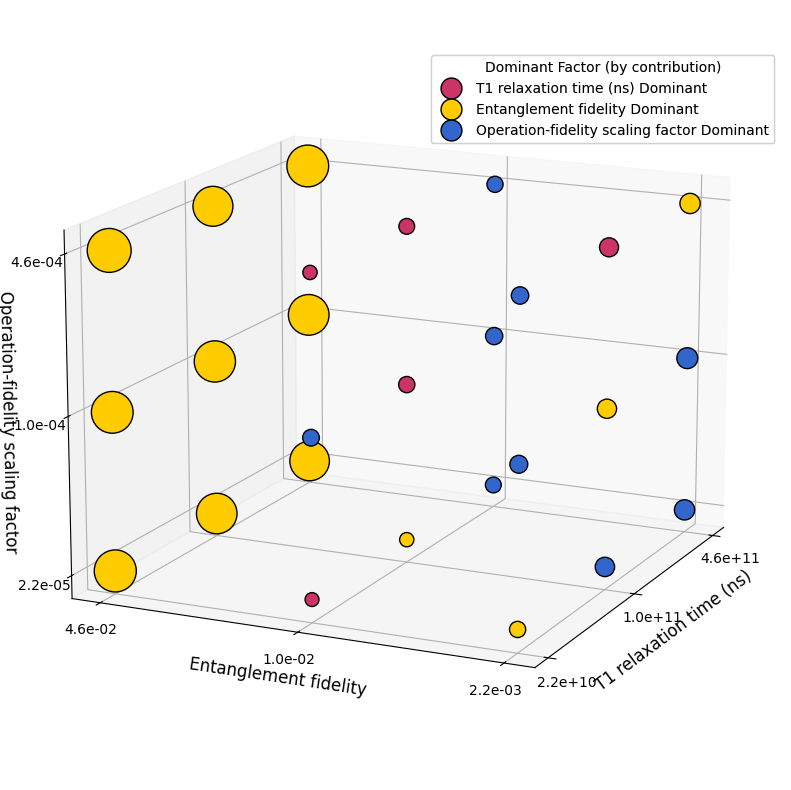

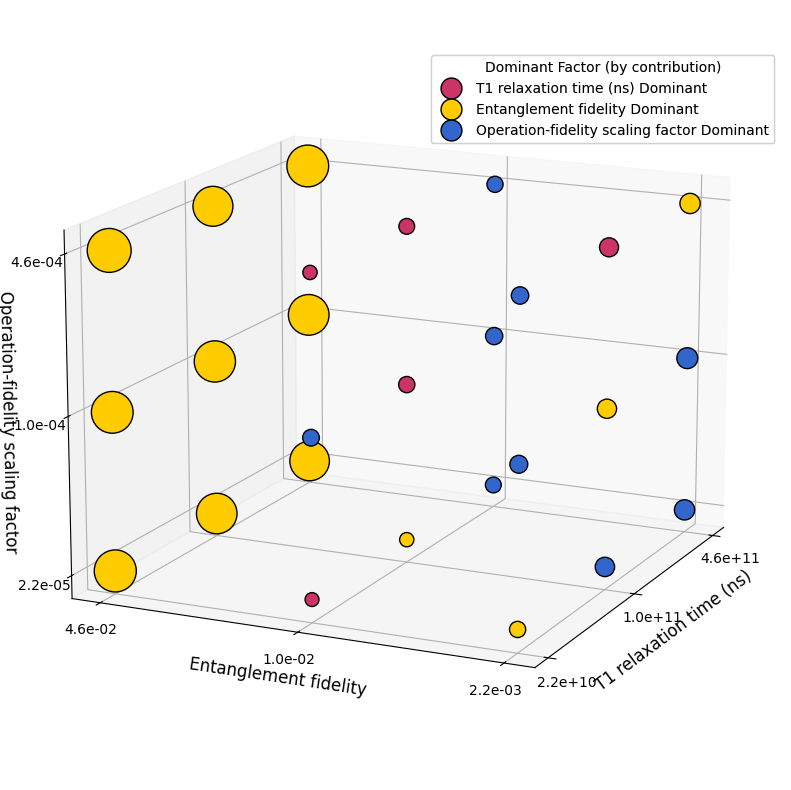

In [54]:
visualize_3d_segments(
    "new_energy_now2.csv",
    param_names=["coherence_time", "entanglement_fidelity", "noise_rate"],
    target_metric_name="target_metric",
    output_file="energy_now.png",
    invert_x_axis=True, invert_y_axis=True,
    use_log_scale=True
)

使用するパラメータ: ['distance', 'entanglement_speed_factor', 'gate_speed_factor']
使用する目標指標: target_metric
使用するスケール: 対数


/var/folders/9l/3nlz01816zq7gp4tbrg6qtk80000gn/T/ipykernel_1049/2246189314.py:209: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


図を保存しました: time_now.png


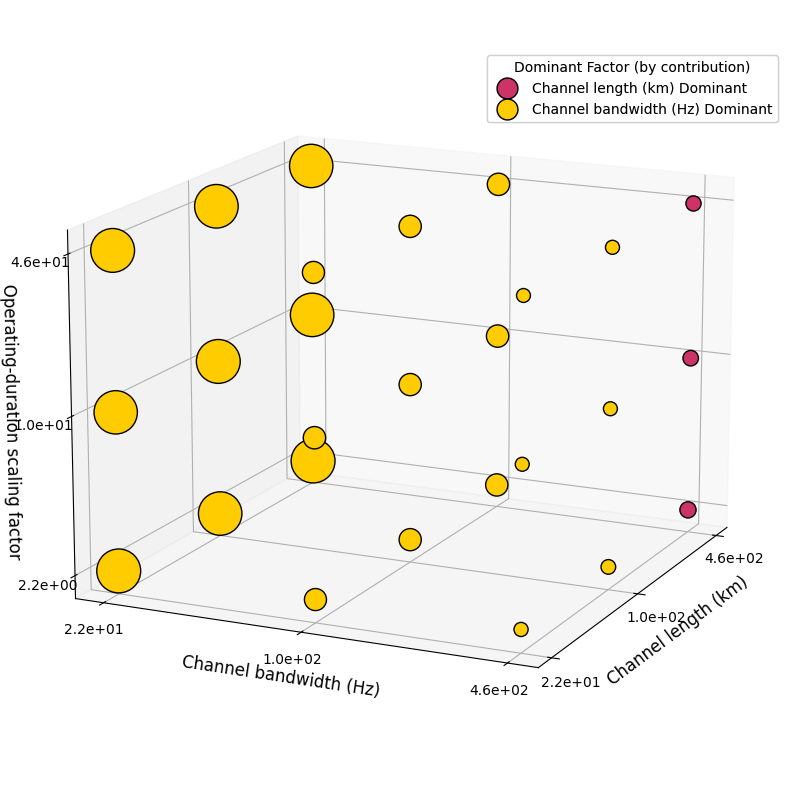

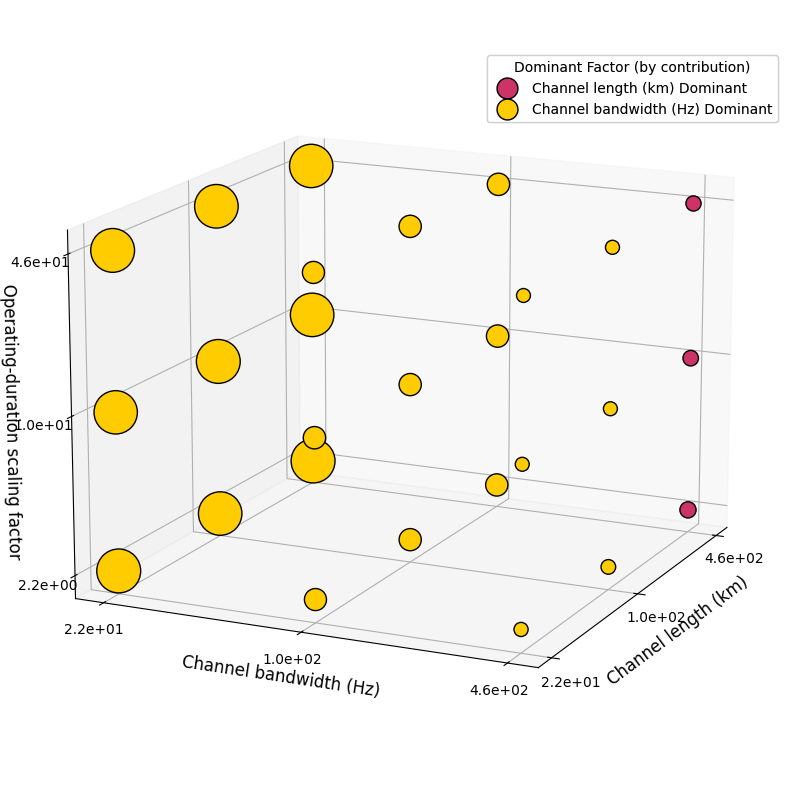

In [53]:
visualize_3d_segments(
    "new_time_now.csv",
    param_names=["distance","entanglement_speed_factor","gate_speed_factor"],
    target_metric_name="target_metric",
    output_file="time_now.png",
    invert_x_axis=True, invert_y_axis=False,
    use_log_scale=True
)

distance,entanglement_speed_factor,gate_speed_factor